In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()


Saving ai4i2020.csv to ai4i2020.csv


In [3]:
df = pd.read_csv('ai4i2020.csv')



In [4]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
X = df[['Air temperature [K]', 'Process temperature [K]',
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=1
)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [11]:
y_pred=model.predict(X_test)

In [12]:
print("Accuracy", accuracy_score(y_test,y_pred))

Accuracy 0.9703333333333334


In [13]:
from sklearn.metrics import confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))

Confusion Matrix:
 [[2892    5]
 [  84   19]]


In [14]:
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      2897
           1       0.79      0.18      0.30       103

    accuracy                           0.97      3000
   macro avg       0.88      0.59      0.64      3000
weighted avg       0.97      0.97      0.96      3000



In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

In [16]:
rf_model=RandomForestClassifier(n_estimators=150,random_state=42, class_weight='balanced')


In [17]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

In [18]:
y_predict_rf=rf_model.predict(X_test)

In [19]:
print("Random Forest Accuracy:", accuracy_score(y_test,y_predict_rf))

Random Forest Accuracy: 0.9813333333333333


In [20]:
print("Confusion matrix:", confusion_matrix(y_test,y_predict_rf))

Confusion matrix: [[2887   10]
 [  46   57]]


In [21]:
print("Classification Report:\n", classification_report(y_test, y_predict_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2897
           1       0.85      0.55      0.67       103

    accuracy                           0.98      3000
   macro avg       0.92      0.77      0.83      3000
weighted avg       0.98      0.98      0.98      3000



In [22]:
importances=rf_model.feature_importances_

In [23]:
feature_names = X_train.shape[1]
print("Number of features used:", feature_names)

Number of features used: 5


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
importances = rf_model.feature_importances_

In [26]:
print("Length of importances array:", len(importances))

Length of importances array: 5


In [27]:
feature_names = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]


In [28]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [35]:
print(feature_importance_df)

                   Feature  Importance
3              Torque [Nm]    0.248058
2   Rotational speed [rpm]    0.231003
4          Tool wear [min]    0.203693
0      Air temperature [K]    0.187751
1  Process temperature [K]    0.129494


In [34]:
plt.figure(figsize=(8,5))


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 'Importance Score')

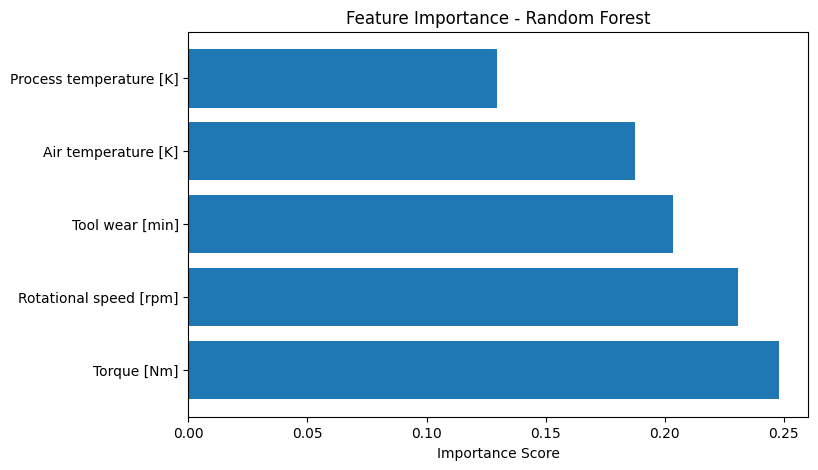

In [36]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")


In [32]:
features = ['Air temperature [K]',
            'Process temperature [K]',
            'Rotational speed [rpm]',
            'Torque [Nm]',
            'Tool wear [min]']
for failure in ['TWF','HDF','PWF','OSF','RNF']:
  print(f"Failure Type: {failure}")
  y=df[failure]
  X=df[features]
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
  rf=RandomForestClassifier(n_estimators=100, random_state=42)
  rf.fit(X_train, y_train)
  y_pred=rf.predict(X_test)
  print(classification_report(y_test, y_pred))
  importances = rf.feature_importances_
  feature_importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
  print(feature_importance_df)

Failure Type: TWF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2989
           1       0.00      0.00      0.00        11

    accuracy                           1.00      3000
   macro avg       0.50      0.50      0.50      3000
weighted avg       0.99      1.00      0.99      3000

                   Feature  Importance
4          Tool wear [min]    0.288186
3              Torque [Nm]    0.213244
2   Rotational speed [rpm]    0.203102
1  Process temperature [K]    0.148053
0      Air temperature [K]    0.147415
Failure Type: HDF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2968
           1       1.00      0.81      0.90        32

    accuracy                           1.00      3000
   macro avg       1.00      0.91      0.95      3000
weighted avg       1.00      1.00      1.00      3000

                   Feature  Importance
0      Air temperature [K]    0.31659

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = ['Air temperature [K]',
            'Process temperature [K]',
            'Rotational speed [rpm]',
            'Torque [Nm]',
            'Tool wear [min]']
importance_matrix = pd.DataFrame(index=['TWF','HDF','PWF','OSF','RNF'], columns=features)


for failure in ['TWF','HDF','PWF','OSF','RNF']:
    y = df[failure]
    X = df[features]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)

    importance_matrix.loc[failure] = rf.feature_importances_

print(importance_matrix)


    Air temperature [K] Process temperature [K] Rotational speed [rpm]  \
TWF              0.0556                0.049628               0.048269   
HDF            0.288112                0.095093               0.432719   
PWF            0.017418                0.016236               0.298251   
OSF            0.009499                0.013707                0.15612   
RNF            0.167945                0.185832               0.189036   

    Torque [Nm] Tool wear [min]  
TWF    0.078665        0.767838  
HDF    0.178826         0.00525  
PWF    0.640441        0.027654  
OSF    0.320254         0.50042  
RNF    0.269935        0.187252  


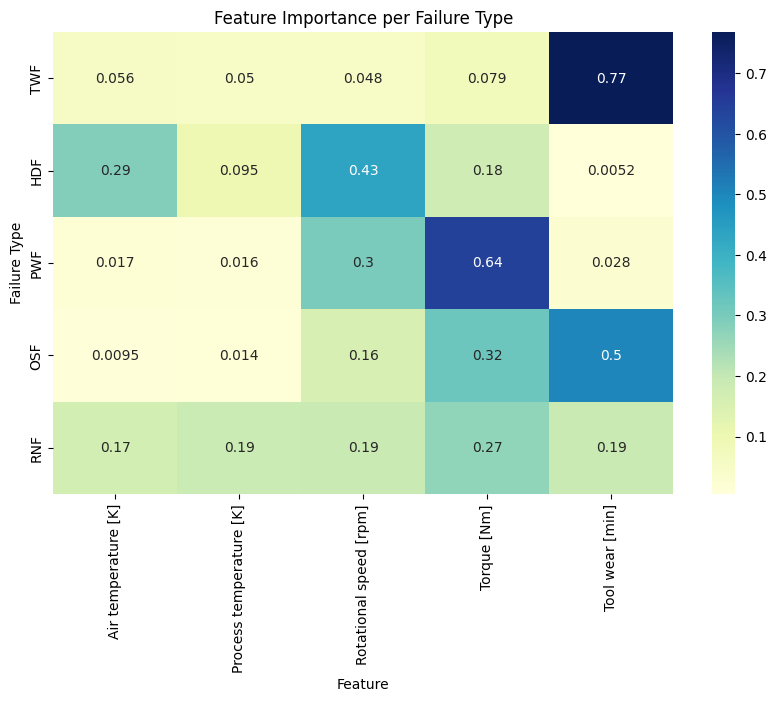

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(importance_matrix.astype(float), annot=True, cmap="YlGnBu")
plt.title("Feature Importance per Failure Type")
plt.ylabel("Failure Type")
plt.xlabel("Feature")
plt.show()
